# Sort spot clean playground

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import skimage.filters as flt
import sys

sys.path.append('../../build-imagingsuite/Release/lib/')
import imgalg as ia

sys.path.append('../../scripts/python')
import amglib.readers as rd


In [9]:
ss = ia.SortSpotClean(True,16,False)

In [10]:
#img = rd.read_image('/Users/Shared/Data/P20241355_stepwedge/02_rawdata/01_data/h2o_5s_00003.fits')
img= rd.read_image('../../TestData/2D/tiff/spots/balls.tif')
#img= rd.read_image('../../TestData/2D/tiff/manyspots.tif')


In [11]:
img2 = np.copy(img).astype('float32')

In [12]:
ss.process(img2,quantile=0.95,th=5,method=ia.eSortSpotQuantile.SortQuantileBright)

Processing 2D image with dimensions:  [1024, 512]


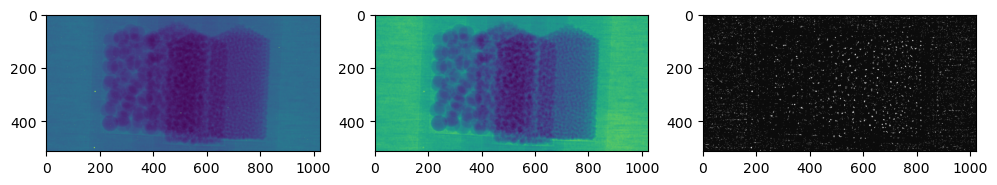

In [13]:
fig,ax = plt.subplots(1,3,figsize=[12,4])
ax[0].imshow(img)
ax[1].imshow(img2)
ax[2].imshow(img-img2,vmin=-1,vmax=20,cmap='gray')

In [14]:
1126*0.44

495.44

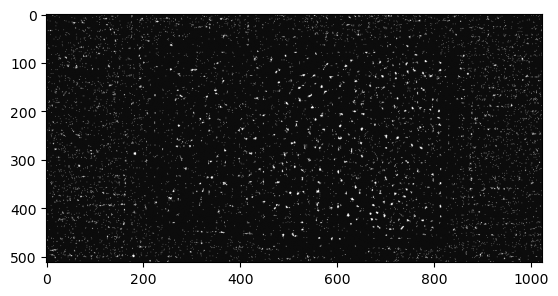

In [15]:
plt.imshow(img-img2,vmin=-1,vmax=20,cmap='gray')

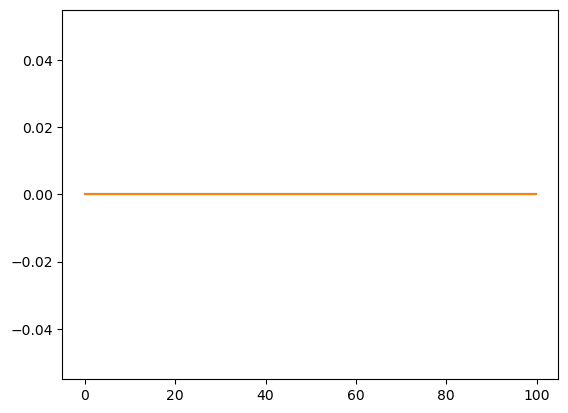

In [16]:
h0=np.histogram(img.ravel(),bins=np.linspace(0,100,512));
h1=np.histogram(img2.ravel(),bins=np.linspace(0,100,512));

plt.plot(h0[1][:-1],h0[0])
plt.plot(h1[1][:-1],h1[0])

# plt.semilogy(h0[1][:-1],h0[0]-h1[0])


In [17]:
mimg = flt.median(img, footprint=np.ones([7,7]))

In [18]:
diff = img-img2

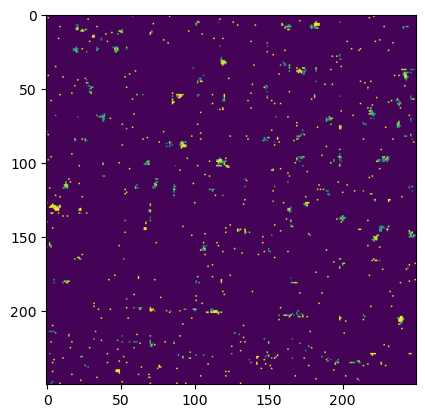

In [19]:
plt.imshow(diff[250:500,250:500],vmin=-10,vmax=1000)

In [31]:
sst = ia.SortSpotClean(True,12, True)

Processing 2D image with dimensions:  [1024, 512]


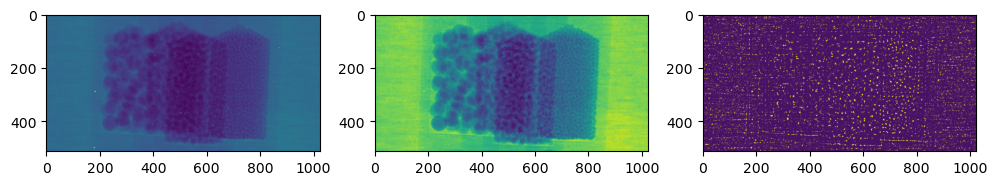

In [32]:
img3 = np.copy(img).astype('float32')
sst.process(img3,quantile=0.9,th=2,method=ia.eSortSpotQuantile.SortQuantileBright)

fig,ax = plt.subplots(1,3,figsize=[12,4])
ax[0].imshow(img)
ax[1].imshow(img3)
ax[2].imshow(img-img3,vmin=-1,vmax=20)

np.float32(1.2836846e+07)

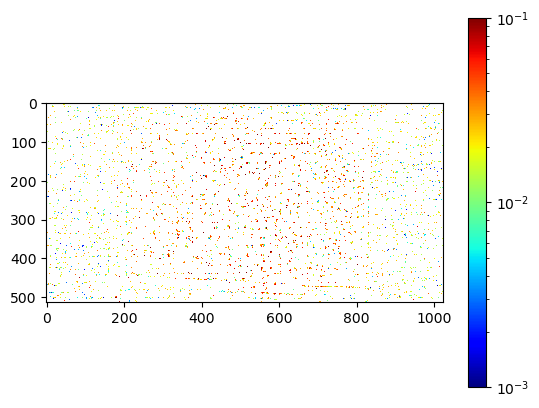

In [42]:
d=img2-img3

# [vmin,vmax]=np.quantile(d.ravel(),[0.01,0.99])
# plt.imshow(d,vmin=vmin,vmax=vmax)
a=plt.imshow(np.abs(d)/img3, norm = LogNorm(vmin=0.001,vmax=0.1),cmap='jet',interpolation='None')
plt.colorbar(a)
d.sum()

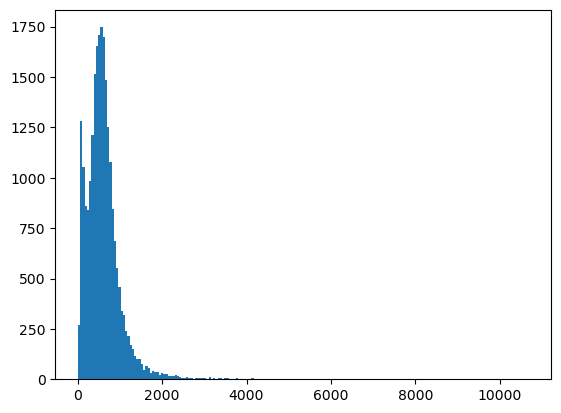

In [34]:
plt.hist(d[0<d].ravel(),bins=200);

Text(0, 0.5, 'Cleaned image')

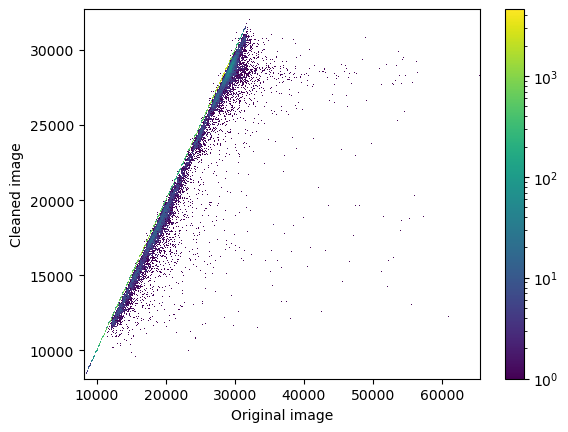

In [16]:

a=plt.hist2d(img.ravel(),img3.ravel(),bins=512,norm=LogNorm());
plt.colorbar()
plt.xlabel('Original image')
plt.ylabel('Cleaned image')

In [17]:
ss.process(img2,quantile=0.95,th=5,method=ia.eSortSpotQuantile.SortQuantileBright)

Processing image with dimensions:  [1024, 512]
Processing 2D image with dimensions:  [1024, 512]


In [18]:
sst.process(img3,quantile=0.95,th=5,method=ia.eSortSpotQuantile.SortQuantileBright)

Processing image with dimensions:  [1024, 512]
Processing 2D image with dimensions:  [1024, 512]


# Process 3D

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import skimage.filters as flt
import sys

sys.path.append('../../build-imagingsuite/Release/lib/')
import imgalg as ia

sys.path.append('../../scripts/python')
import amglib.readers as rd

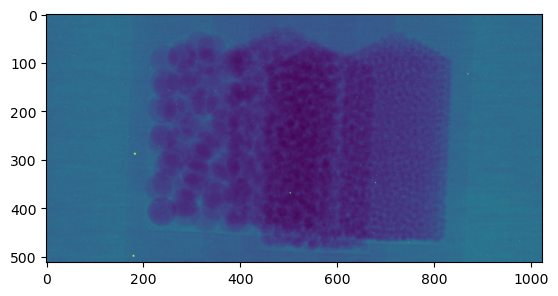

In [25]:
#img = rd.read_image('/Users/Shared/Data/P20241355_stepwedge/02_rawdata/01_data/h2o_5s_00003.fits')
img= rd.read_image('../../TestData/2D/tiff/spots/balls.tif').astype('float32')
#img= rd.read_image('../../TestData/2D/tiff/manyspots.tif')
plt.imshow(img)

In [31]:
ss  = ia.SortSpotClean(True,32,False)
sst = ia.SortSpotClean(True,32,True)

In [32]:
# Prepare 3D image
N=200

N0 = img.shape[0] // N
N1 = img.shape[1] // N

vol = np.zeros([N0*N1,N,N],dtype='float32')

i = 0
for r in range(N0) :
    for c in range(N1) :
        vol[i]=img[(r*N):(r*N+N),(c*N):(c*N+N)]
        i=i+1
        
print(vol.shape)

(10, 200, 200)


In [33]:
vol2D=vol.copy()

for i in range(vol.shape[0]) :
    tmp = vol2D[i]
    sst.process(tmp,quantile=0.95,th=5,method=ia.eSortSpotQuantile.SortQuantileBright)
    vol2D[i] = tmp

Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]


In [37]:
vol3D=vol.copy()

sst.process(vol3D,quantile=0.95,th=5,method=ia.eSortSpotQuantile.SortQuantileBright)

Processing 3D image with dimensions:  [200, 200, 10]


Text(0.5, 1.0, '2D-3D')

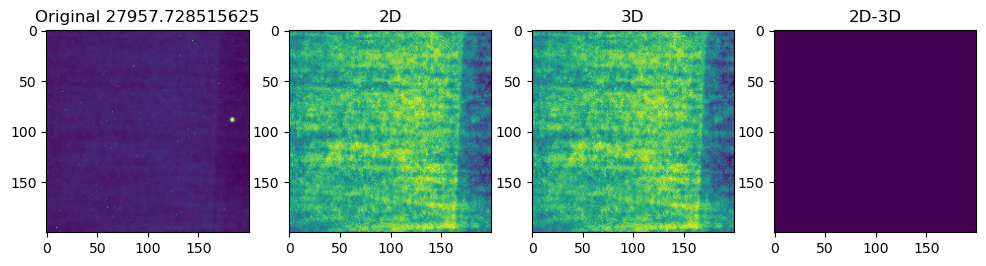

In [38]:
fig,ax = plt.subplots(1,4,figsize=(12,5))
idx = 5
ax[0].imshow(vol[idx])
ax[0].set_title(f'Original {vol[idx].mean()}')

ax[1].imshow(vol2D[idx])
ax[1].set_title('2D')

ax[2].imshow(vol3D[idx])
ax[2].set_title('3D')

ax[3].imshow(0<(vol2D[idx]-vol3D[idx]))
ax[3].set_title('2D-3D')


In [39]:
0.2*1126

225.20000000000002